# Notebook C of line ratios from saved maps from the PZ cube

This is from the splitting up of ZZ-01-01-more-line-ratios.ipynb. It includes analysis of the He I and He II lines

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Path to the root of this repo

In [2]:
ROOT = Path.cwd().parent.parent

In [3]:
mapspath = ROOT / "data/n346-bow-lines/refined"

In [5]:
def get_image(lineid, combo="P-007", ext="SUM"):
    im = Image(str(mapspath / f"map-{lineid}-{combo}.fits"), ext=ext)
    im.data = im.data.astype(float)
    return im


def get_image_raw(lineid, variant="csub", channel="ABC"):
    p = ROOT / "data" / "n346-bow-lines" / f"maps-n346-PZ-2pass-{variant}-007"
    candidates = list(p.glob(f"**/*-{lineid}-{channel}.fits"))
    assert candidates
    imfile = candidates[0]
    im = Image(str(imfile))
    im.data = im.data.astype(float)
    return im

## Reddening law for SMC

In [14]:
rc = pn.RedCorr()
rc.R_V = 2.74
rc.FitzParams = [-4.96, 2.26, 0.39, 0.6, 4.6, 1.0]
rc.law = "F99"

## Calculate He I / Hβ

Let us see if this has a hole in it where the He II is coming from.
+

In [7]:
im5875 = get_image_raw("he-i-5875-62")
im4922 = get_image_raw("he-i-4921-93")
im5048 = get_image_raw("he-i-5047-74")
im5016 = get_image_raw("he-i-5015-68")
im6678 = get_image_raw("he-i-6678-15")
im7065 = get_image_raw("he-i-7065-28")
im7281 = get_image_raw("he-i-7281-35")

imhb = get_image_raw("h-i-4861-32")

Text(0.5, 1.0, 'He I 7065')

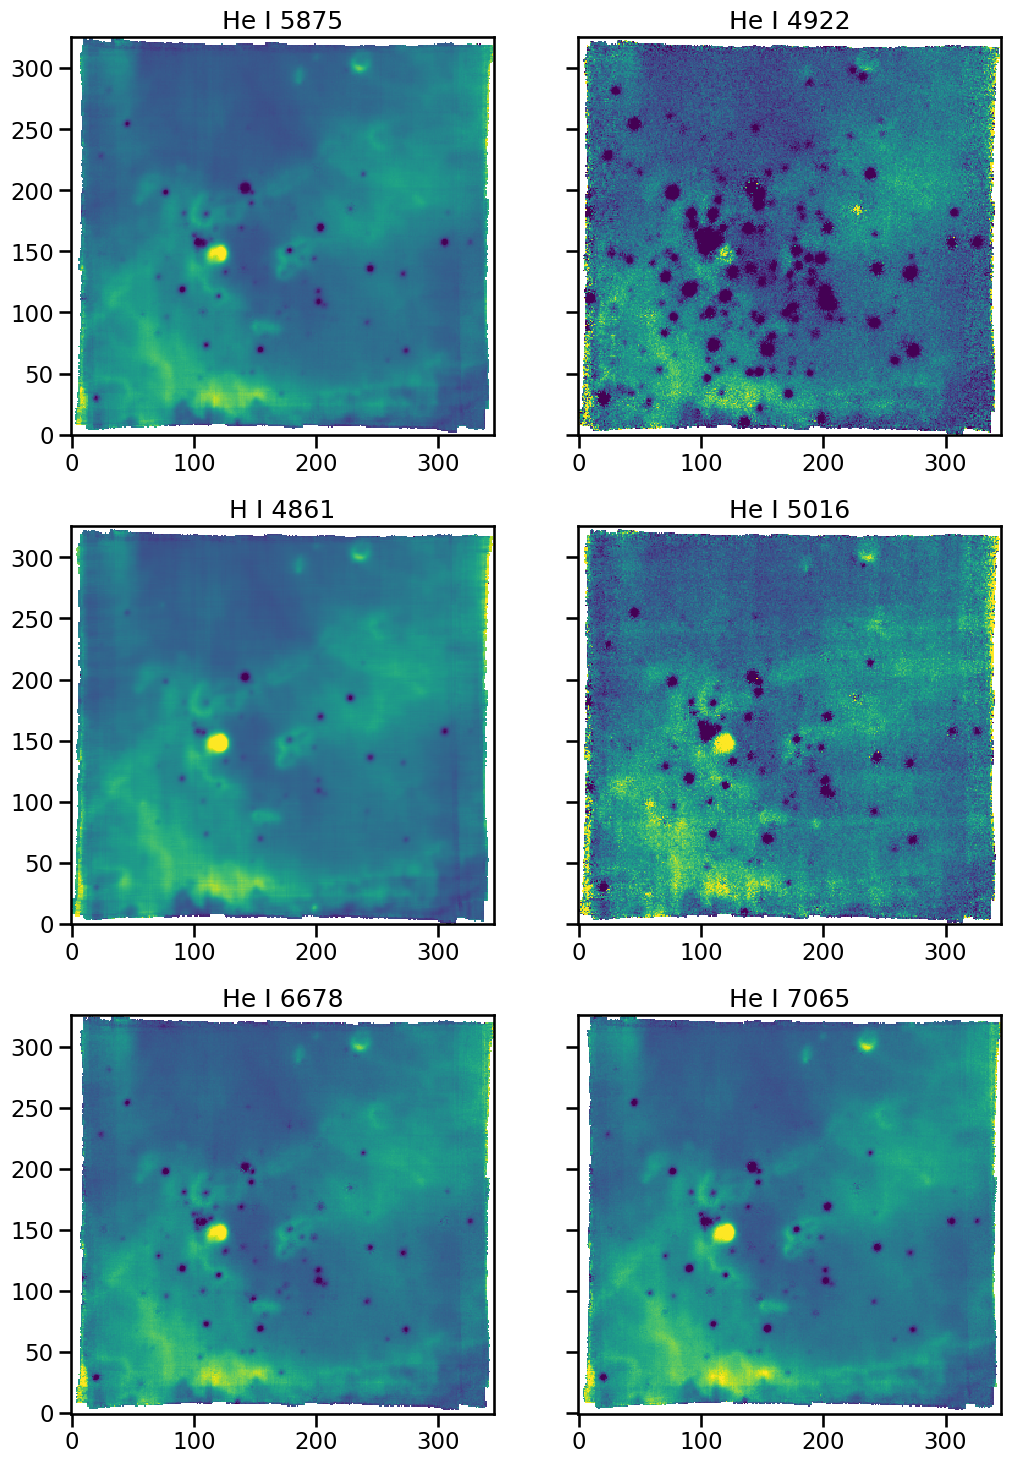

In [8]:
fig, axes = plt.subplots(3, 2, sharey=True, figsize=(12, 18))
im5875.plot(ax=axes[0, 0], vmin=0, vmax=7500)
im4922.plot(ax=axes[0, 1], vmin=0, vmax=550)
(imhb).plot(ax=axes[1, 0], vmin=0, vmax=60000)
im5016.plot(ax=axes[1, 1], vmin=0, vmax=700)
im6678.plot(ax=axes[2, 0], vmin=0, vmax=2000)
im7065.plot(ax=axes[2, 1], vmin=0, vmax=1400)
axes[0, 0].set_title("He I 5875")
axes[0, 1].set_title("He I 4922")
axes[1, 0].set_title("H I 4861")
axes[1, 1].set_title("He I 5016")
axes[2, 0].set_title("He I 6678")
axes[2, 1].set_title("He I 7065")

So 5875 is 10 to 100 times brighter than the other two. And it is almost identical to Hβ!

Text(0.5, 0.98, 'Correlation between Hβ 4861 and He I 5875 brightness')

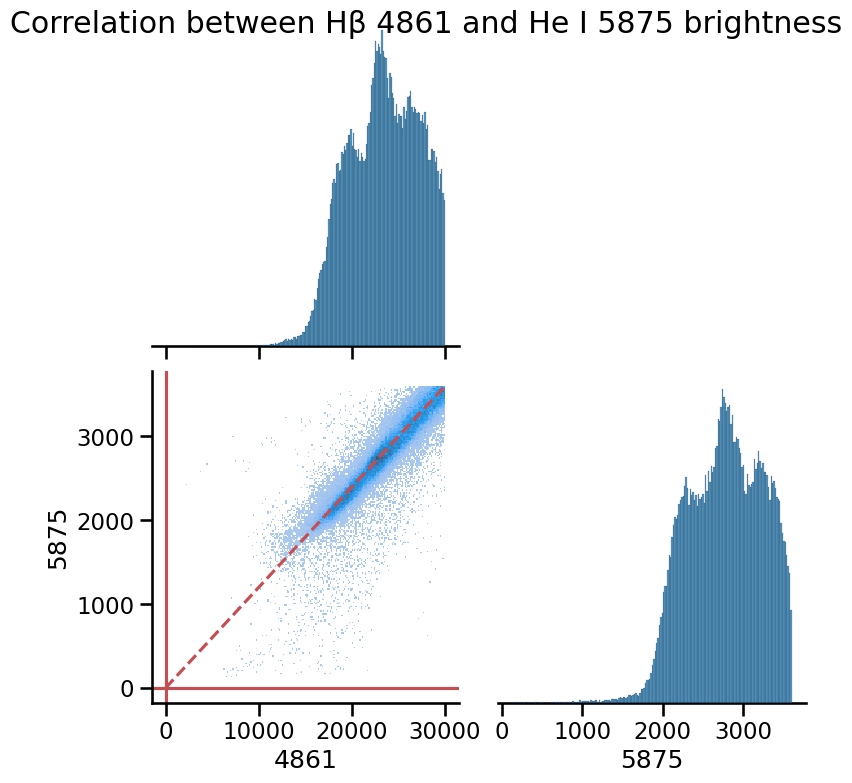

In [9]:
imax = 30000
imin = 1000
slope = 0.12
x = imhb.data
y = im5875.data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > imin * slope)
m = m & ~imhb.mask & ~im5875.mask
df = pd.DataFrame(
    {
        "4861": x[m],
        "5875": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=x[m], bins=200),
    diag_kws=dict(weights=x[m], bins=200),
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.fig.suptitle("Correlation between Hβ 4861 and He I 5875 brightness")

Text(0.5, 0.98, 'Correlation between Hβ 4861 and He I 5875 brightness')

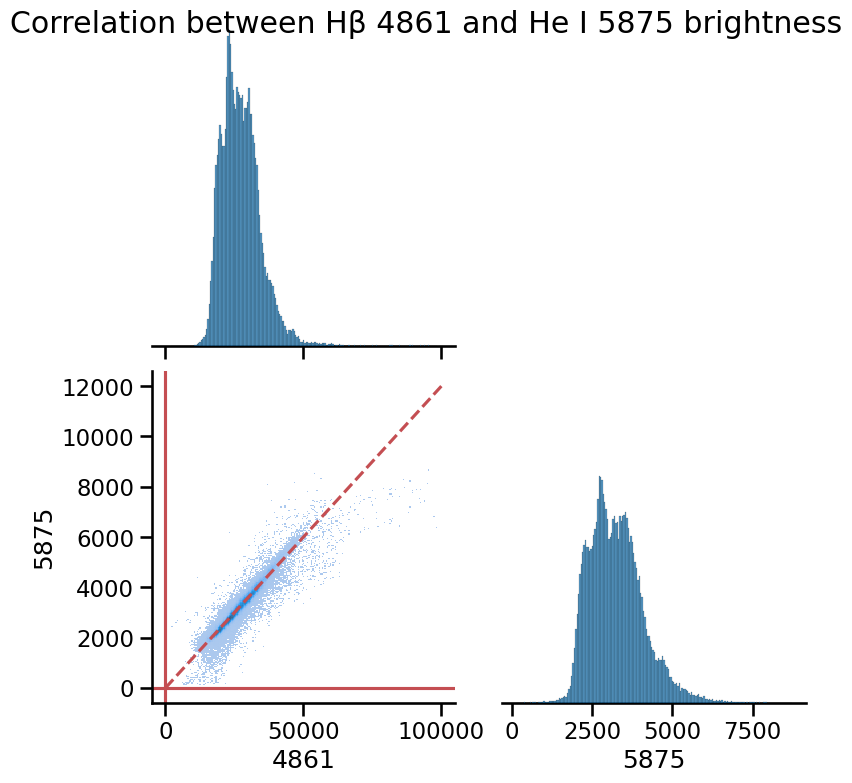

In [10]:
imax = 100000
imin = 1000
slope = 0.12
x = imhb.data
y = im5875.data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > imin * slope)
m = m & ~imhb.mask & ~im5875.mask
df = pd.DataFrame(
    {
        "4861": x[m],
        "5875": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=x[m], bins=200),
    diag_kws=dict(weights=x[m], bins=200),
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.fig.suptitle("Correlation between Hβ 4861 and He I 5875 brightness")

In [12]:
imEBV = Image(str(ROOT / "data/ngc346-ZZ-reddening-E_BV.fits"))

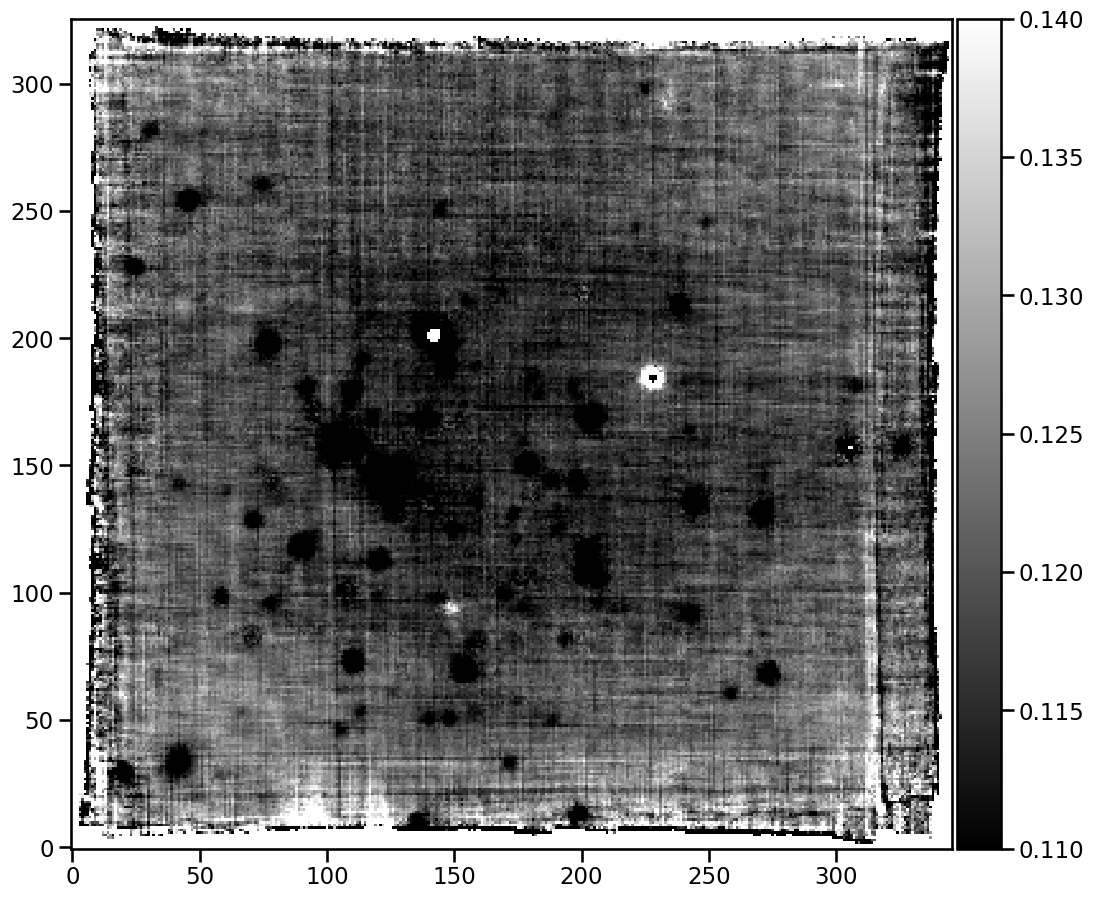

In [16]:
imR_hei_hb = im5875 / (imhb)

fig, ax = plt.subplots(figsize=(12, 12))
imR_hei_hb.plot(colorbar="v", cmap="gray", vmin=0.11, vmax=0.14)

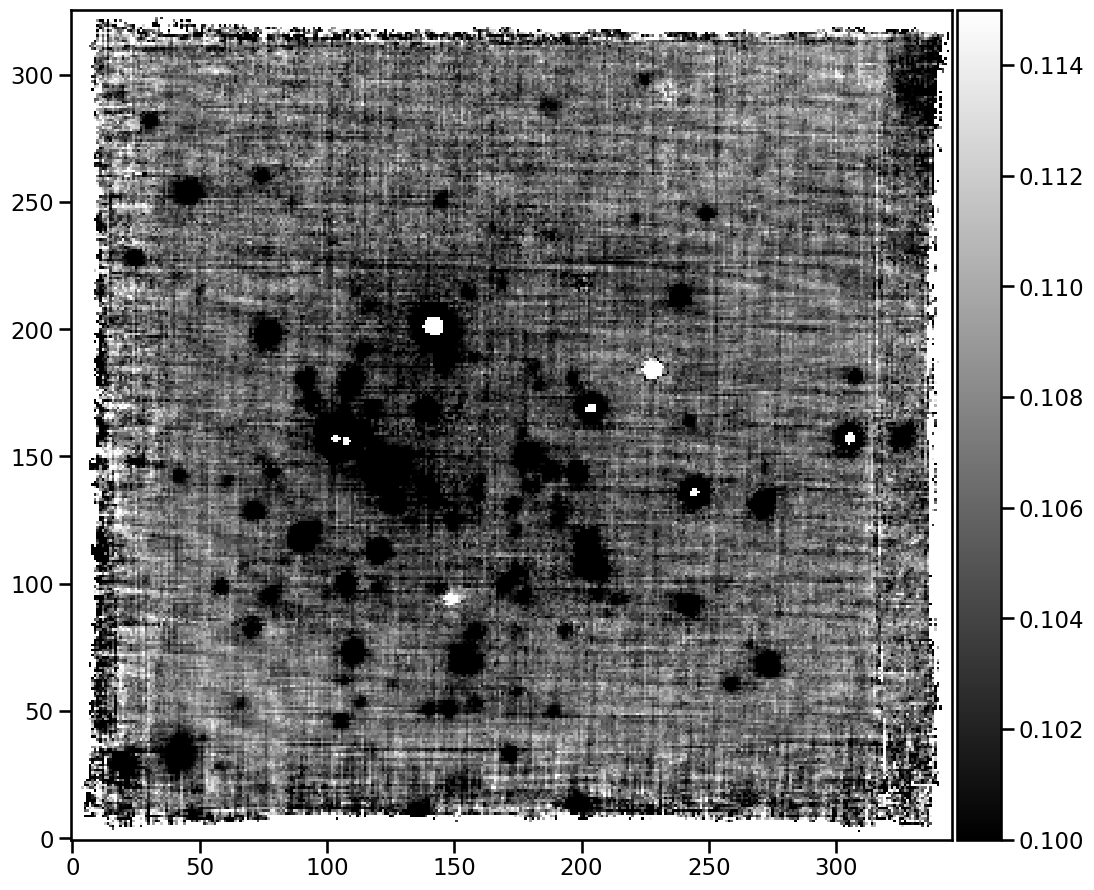

In [17]:
red_R_hei_hb = imR_hei_hb.copy()
red_R_hei_hb.data = 10 ** (0.4 * imEBV.data * (rc.X(4861) - rc.X(5875)))

fig, ax = plt.subplots(figsize=(12, 12))
(imR_hei_hb / red_R_hei_hb).plot(colorbar="v", cmap="gray", vmin=0.1, vmax=0.115)

So if we correct it for reddening, then lots of spurious structure disappears.  But we are left with very little variation at all, except for at the mYSO and the top right corner, which both show low He I.

### He I emissivities

In [18]:
hei = pn.RecAtom("He", 1)

dens = [10, 50, 100, 200, 400, 800]
tems = [11000, 13000, 15000, 18000]
e4713 = hei.getEmissivity(tems, dens, wave=4713)
e4921 = hei.getEmissivity(tems, dens, wave=4921)
e5016 = hei.getEmissivity(tems, dens, wave=5016)
e5047 = hei.getEmissivity(tems, dens, wave=5047)
e5876 = hei.getEmissivity(tems, dens, wave=5876)
e6678 = hei.getEmissivity(tems, dens, wave=6678)
e7065 = hei.getEmissivity(tems, dens, wave=7065)
e7281 = hei.getEmissivity(tems, dens, wave=7281)

In [20]:
np.round(e5016 / e5876, 3)

array([[0.217, 0.217, 0.217, 0.215, 0.214, 0.212],
       [0.229, 0.228, 0.228, 0.224, 0.221, 0.217],
       [0.239, 0.238, 0.237, 0.23 , 0.224, 0.219],
       [0.253, 0.249, 0.248, 0.236, 0.227, 0.218]])

In [21]:
np.round(e5876 / e6678, 3)

array([[3.521, 3.522, 3.523, 3.526, 3.529, 3.532],
       [3.53 , 3.53 , 3.53 , 3.531, 3.533, 3.534],
       [3.538, 3.535, 3.534, 3.531, 3.528, 3.525],
       [3.548, 3.539, 3.535, 3.521, 3.508, 3.498]])

In [22]:
np.round((e7281 + e7065) / e6678, 3)

array([[0.828, 0.847, 0.855, 0.912, 0.966, 1.018],
       [0.91 , 0.935, 0.946, 1.02 , 1.089, 1.153],
       [0.989, 1.018, 1.031, 1.114, 1.188, 1.256],
       [1.102, 1.133, 1.145, 1.226, 1.294, 1.352]])

In [23]:
np.round(e4713 / e5876, 3)

array([[0.04 , 0.04 , 0.041, 0.041, 0.042, 0.042],
       [0.045, 0.045, 0.045, 0.046, 0.046, 0.047],
       [0.049, 0.05 , 0.05 , 0.05 , 0.05 , 0.051],
       [0.056, 0.056, 0.056, 0.056, 0.056, 0.056]])

### He I T-sensitive ratio

The (7065 + 7281)/6678 ratio depends on density and temperature

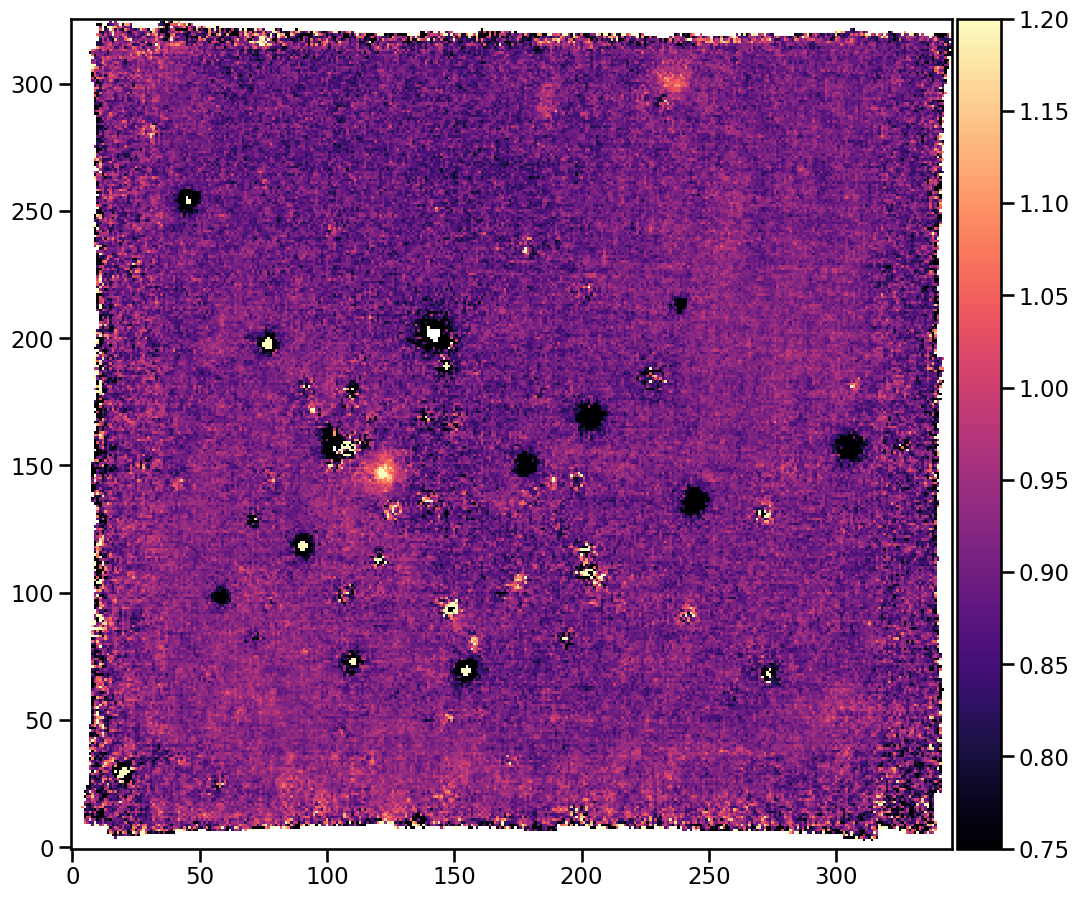

In [24]:
fig, ax = plt.subplots(figsize=(12, 12))
((im7065 + im7281) / im6678).plot(colorbar="v", cmap="magma", vmin=0.75, vmax=1.2)

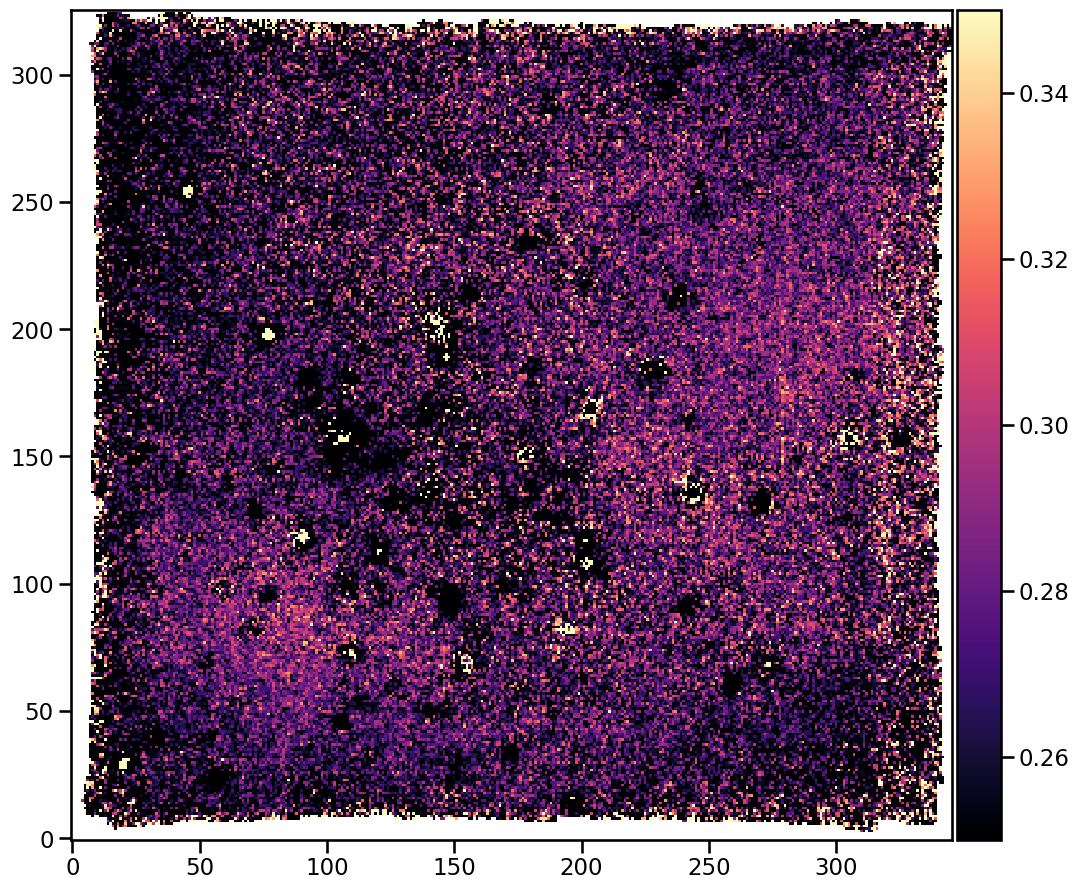

In [25]:
fig, ax = plt.subplots(figsize=(12, 12))
(im7281 / im7065).plot(colorbar="v", cmap="magma", vmin=0.25, vmax=0.35)

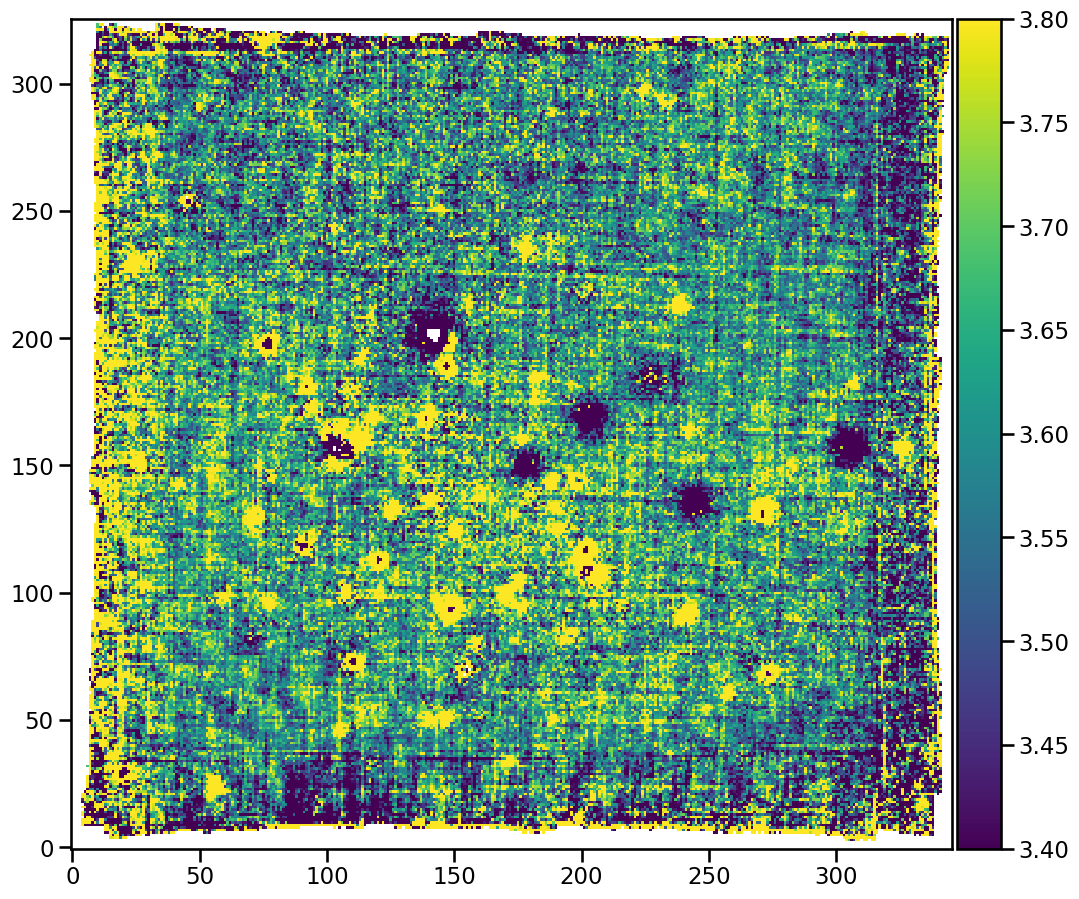

In [26]:
fig, ax = plt.subplots(figsize=(12, 12))
(im5875 / im6678).plot(colorbar="v", cmap="viridis", vmin=3.4, vmax=3.8)

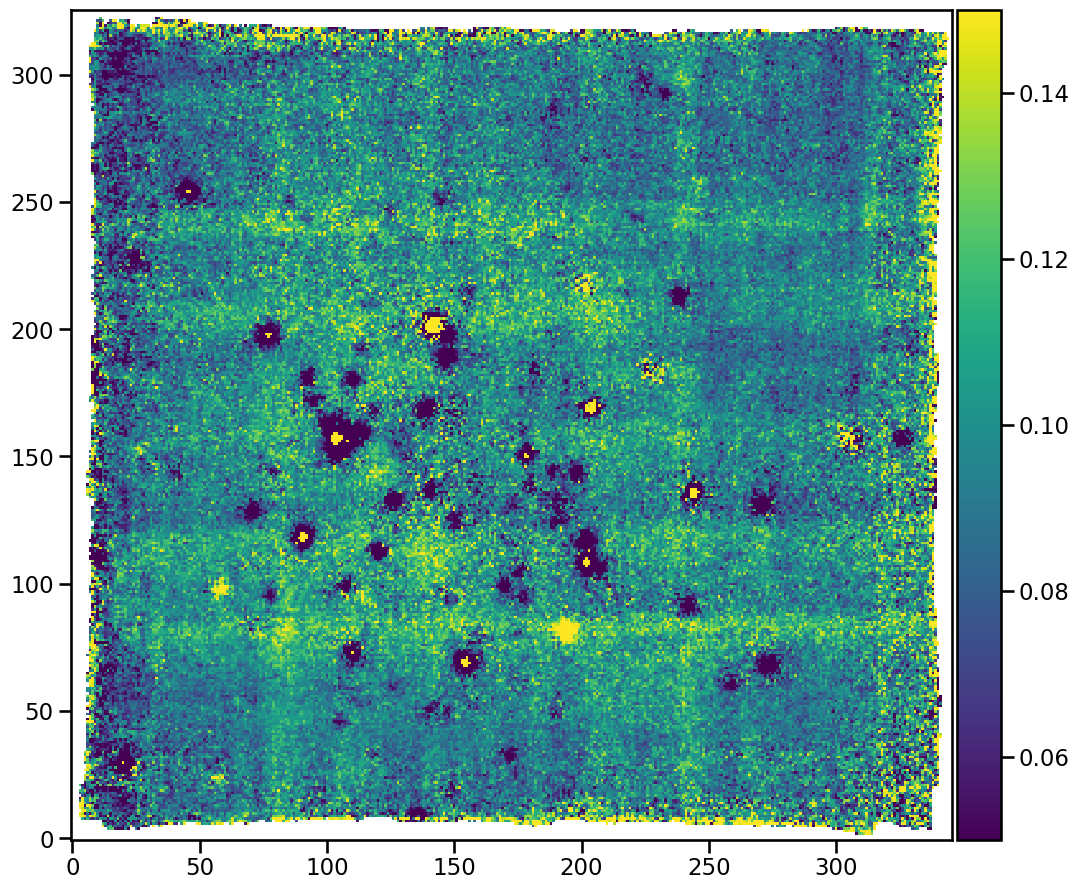

In [27]:
fig, ax = plt.subplots(figsize=(12, 12))
(im5016 / im5875).plot(colorbar="v", cmap="viridis", vmin=0.05, vmax=0.15)

## Calculate He II / Hβ



In [28]:
im4686 = get_image_raw("he-ii-4685-68")

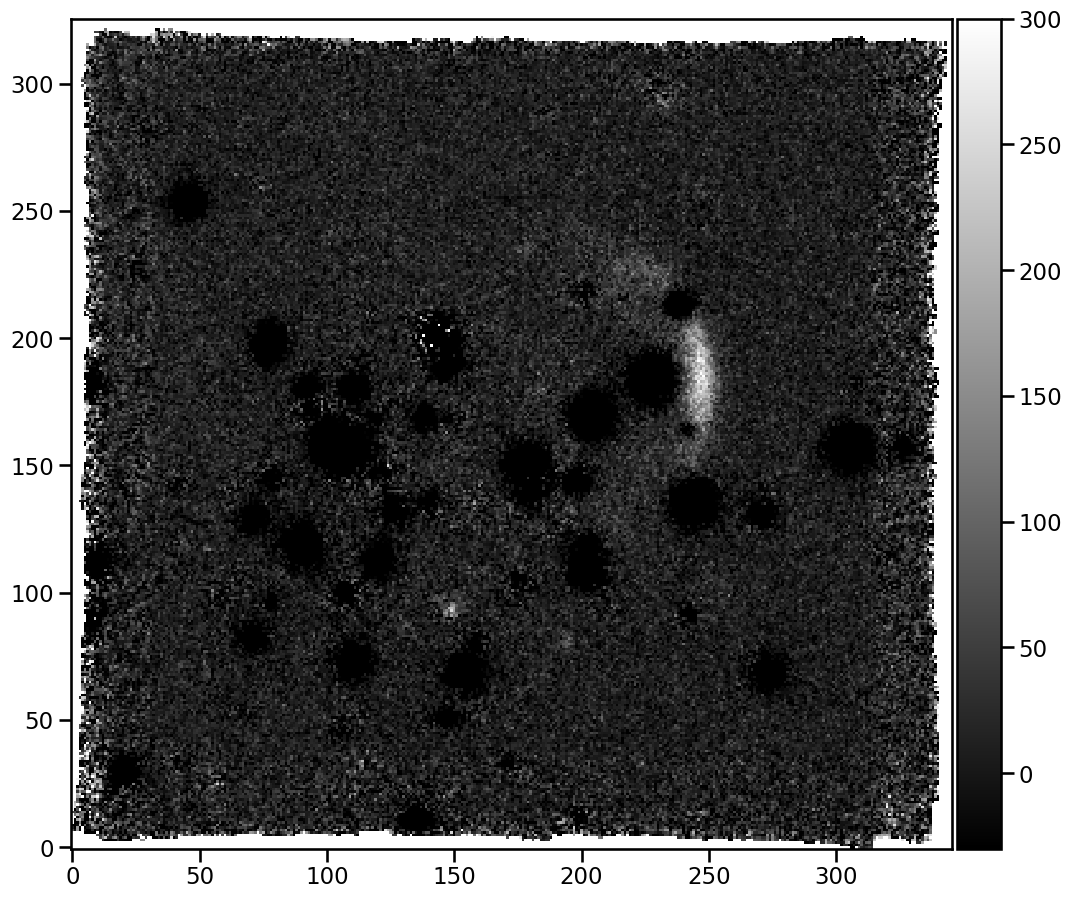

In [29]:
fig, ax = plt.subplots(figsize=(12, 12))
im4686.plot(colorbar="v", cmap="gray", vmin=-30.0, vmax=300)

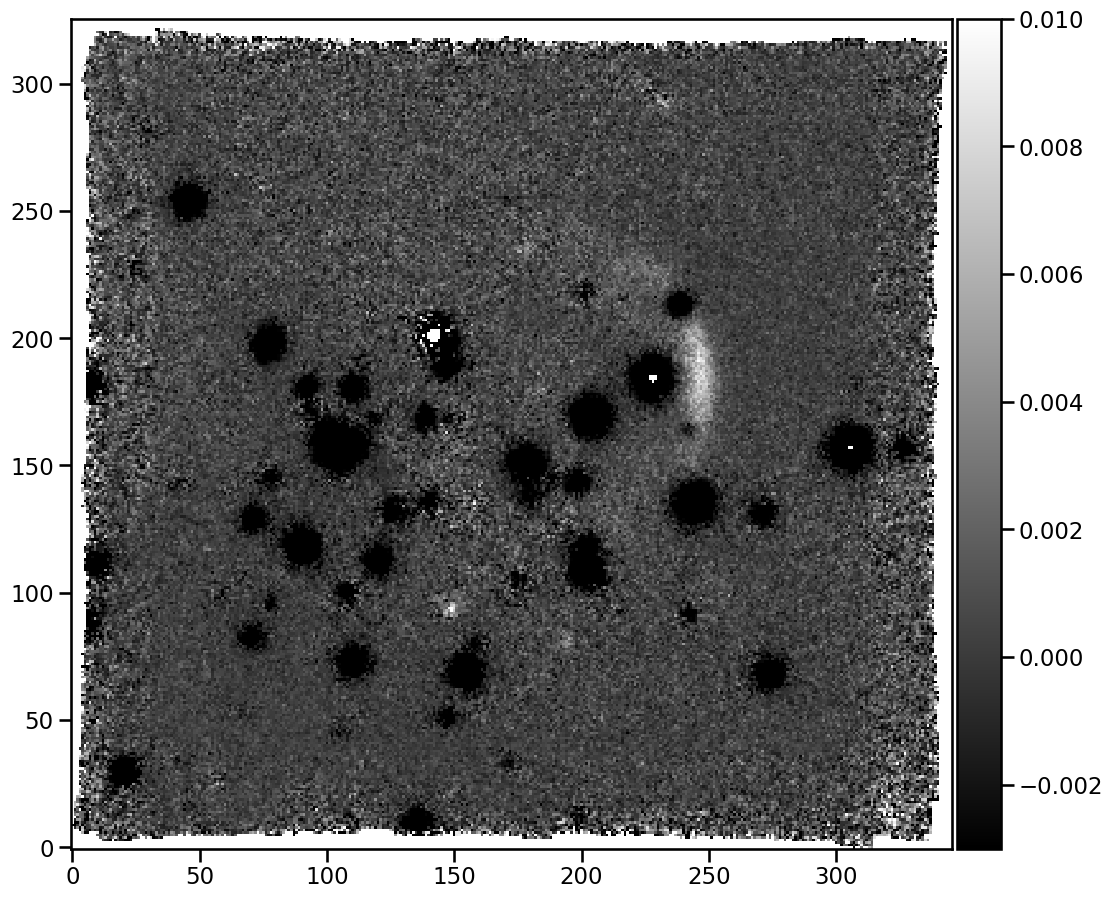

In [30]:
imR_heii_hb = im4686 / imhb

fig, ax = plt.subplots(figsize=(12, 12))
imR_heii_hb.plot(colorbar="v", cmap="gray", vmin=-0.003, vmax=0.01)

Text(0.5, 0.98, 'Correlation between He II / Hβ and He I / Hβ ratios')

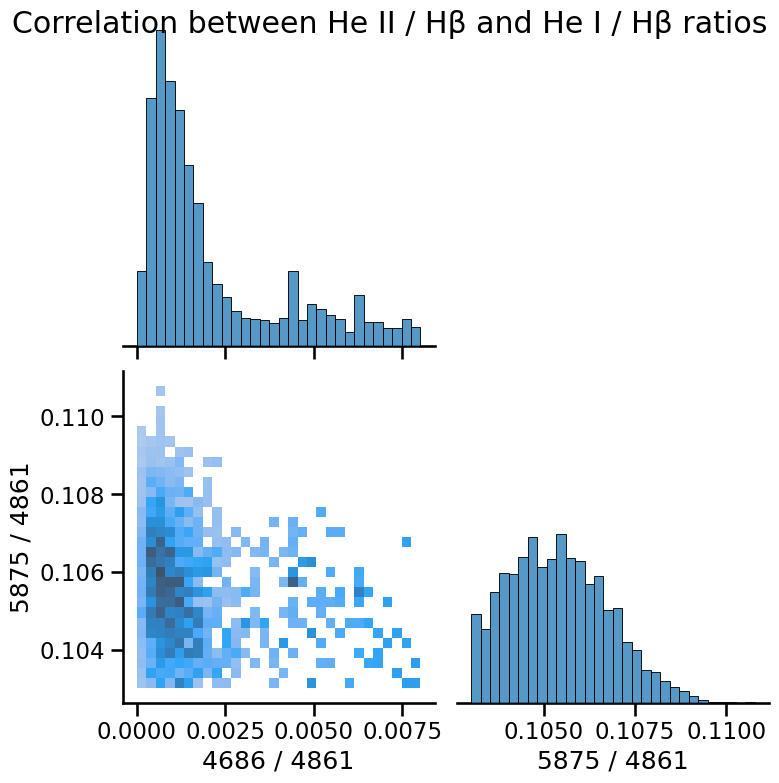

In [31]:
n = 2
xslice, yslice = slice(200, 300), slice(100, 250)
x = imR_heii_hb[yslice, xslice].rebin(n).data
y = (
    imR_hei_hb[yslice, xslice].rebin(n).data
    / red_R_hei_hb[yslice, xslice].rebin(n).data
)
z = im4686[yslice, xslice].rebin(n).data
m = x < 0.03
m = m & (x > 0)
m = m & (y < 0.113)
m = m & (y > 0.103)
m = (
    m
    & ~imR_heii_hb[yslice, xslice].rebin(n).mask
    & ~imR_hei_hb[yslice, xslice].rebin(n).mask
)
df = pd.DataFrame(
    {
        "4686 / 4861": x[m],
        "5875 / 4861": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=30),
    diag_kws=dict(weights=z[m], bins=30),
)
g.fig.suptitle("Correlation between He II / Hβ and He I / Hβ ratios")

So there is a *tiny* change in 5875/4861 from 0.109 to 0.107 as 4686/4861 increases.

In [32]:
df["high"] = df["4686 / 4861"] > 0.005
df

,4686 / 4861,5875 / 4861,high
0,0.000456,0.104744,False
1,0.000015,0.103495,False
2,0.001615,0.106001,False
3,0.000686,0.105375,False
4,0.000410,0.105410,False
...,...,...,...
2437,0.000456,0.106067,False
2438,0.000342,0.105009,False
2439,0.000306,0.104888,False
2440,0.000108,0.103916,False


<Axes: xlabel='5875 / 4861', ylabel='Probability'>

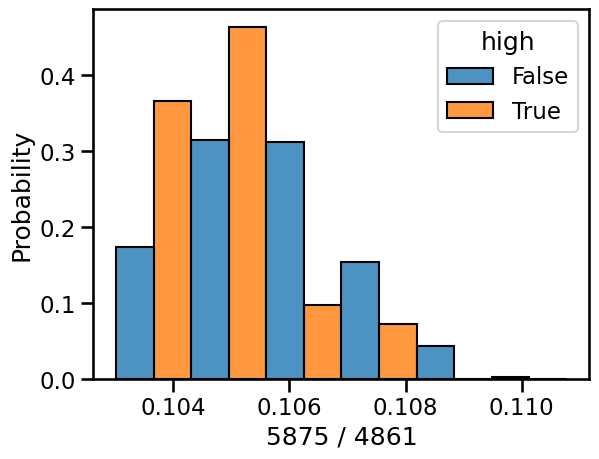

In [33]:
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    multiple="dodge",
    shrink=1.0,
    stat="probability",
    common_norm=False,
    alpha=0.8,
    bins=6,
)

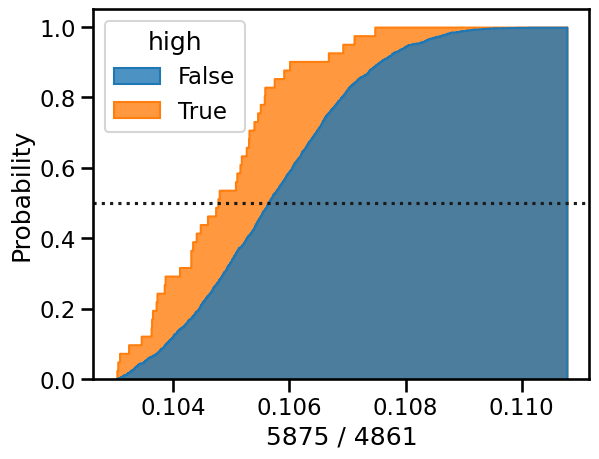

In [34]:
df["high"] = df["4686 / 4861"] > 0.005
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    # multiple="dodge",
    shrink=1.0,
    stat="probability",
    cumulative=True,
    common_norm=False,
    alpha=0.8,
    bins=1000,
    element="step",
).axhline(0.5, linestyle="dotted", color="k")

Try to remove the pattern noise

In [35]:
imR_heii_hb_fake = imR_heii_hb.copy()
m = imR_heii_hb_fake.data > 0.01
imR_heii_hb_fake.data[m] = np.nan
vv = np.nanmedian(imR_heii_hb_fake.data, axis=0, keepdims=True)
hh = np.nanmedian(imR_heii_hb_fake.data, axis=1, keepdims=True)
imR_heii_hb_fake.data = vv + hh
imR_heii_hb_fake.data -= np.nanmedian(vv + hh)
imR_heii_hb_c = imR_heii_hb.copy()
imR_heii_hb_c.data -= imR_heii_hb_fake.data

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_97748/1126909528.py:4: RuntimeWarning: All-NaN slice encountered
  vv = np.nanmedian(imR_heii_hb_fake.data, axis=0, keepdims=True)
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_97748/1126909528.py:5: RuntimeWarning: All-NaN slice encountered
  hh = np.nanmedian(imR_heii_hb_fake.data, axis=1, keepdims=True)


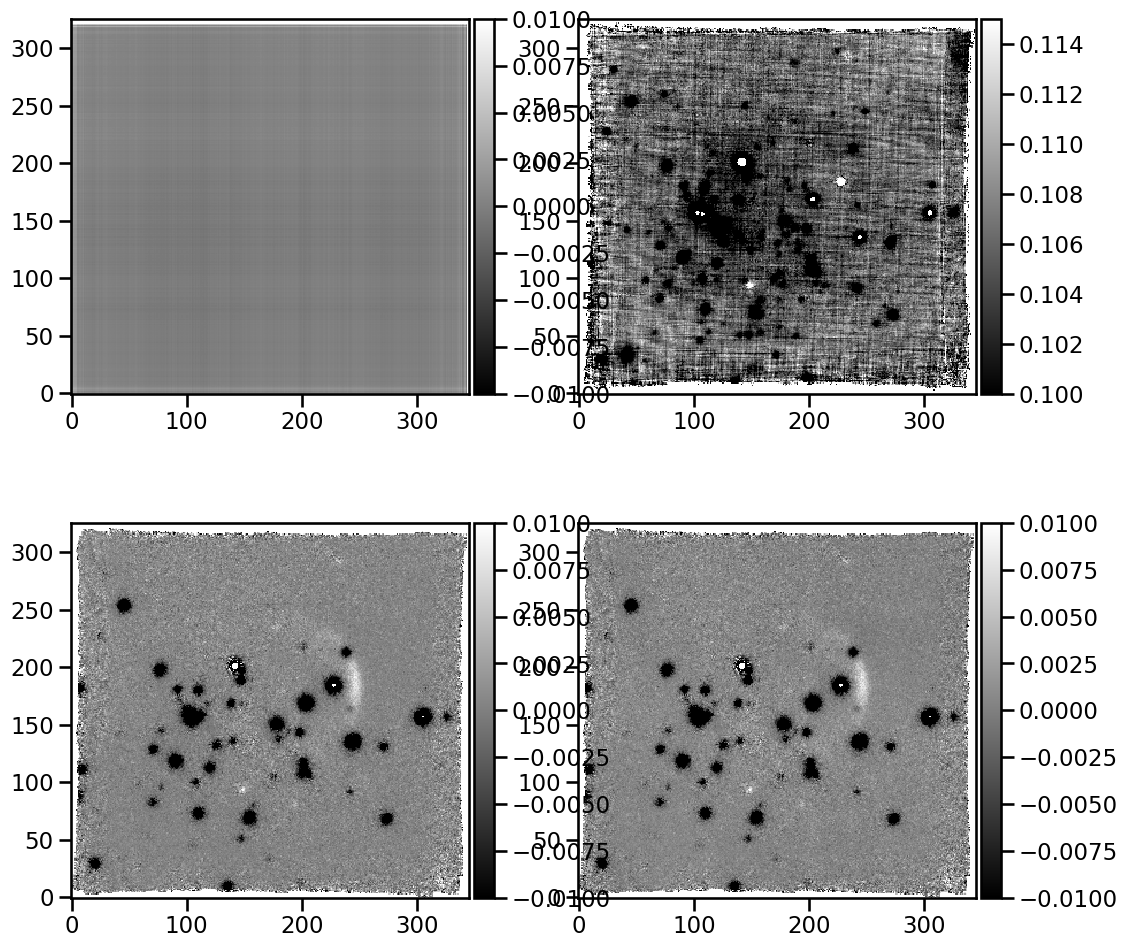

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
imR_heii_hb_fake.plot(ax=axes[0, 0], colorbar="v", cmap="gray", vmin=-0.01, vmax=0.01)
(imR_hei_hb / red_R_hei_hb).plot(
    ax=axes[0, 1], colorbar="v", cmap="gray", vmin=0.1, vmax=0.115
)
imR_heii_hb.plot(ax=axes[1, 0], colorbar="v", cmap="gray", vmin=-0.01, vmax=0.01)
imR_heii_hb_c.plot(ax=axes[1, 1], colorbar="v", cmap="gray", vmin=-0.01, vmax=0.01)

Text(0.5, 0.98, 'Correlation between He II / Hβ and He I / Hβ ratios')

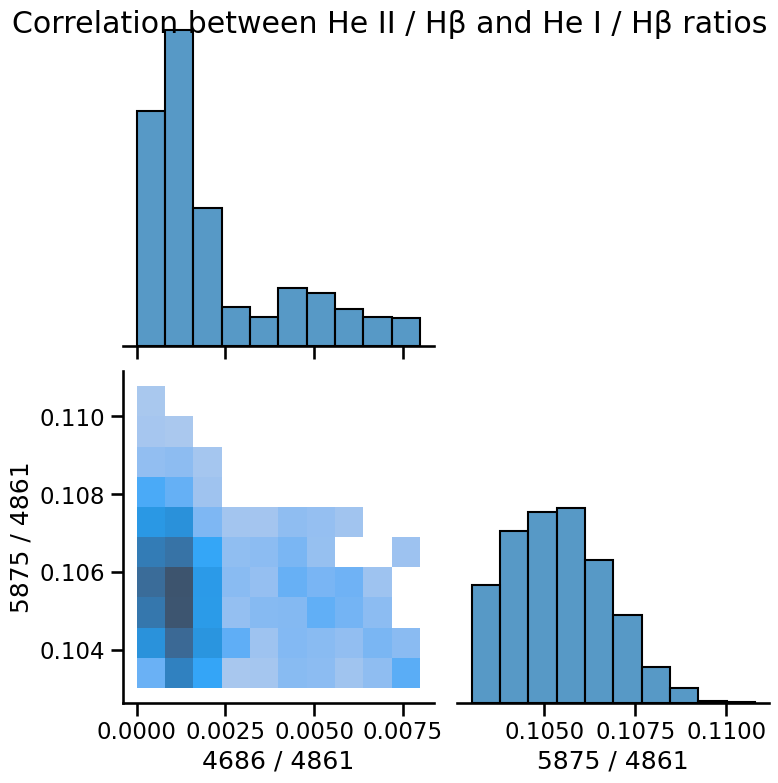

In [37]:
n = 2
xslice, yslice = slice(200, 300), slice(100, 250)
# xslice, yslice = slice(230, 300), slice(130, 220)
x = imR_heii_hb_c[yslice, xslice].rebin(n).data
y = (
    imR_hei_hb[yslice, xslice].rebin(n).data
    / red_R_hei_hb[yslice, xslice].rebin(n).data
)
z = im4686[yslice, xslice].rebin(n).data
m = x < 0.03
m = m & (x > 0)
m = m & (y < 0.113)
m = m & (y > 0.103)
m = (
    m
    & ~imR_heii_hb[yslice, xslice].rebin(n).mask
    & ~imR_hei_hb[yslice, xslice].rebin(n).mask
)
df = pd.DataFrame(
    {
        "4686 / 4861": x[m],
        "5875 / 4861": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=10),
    diag_kws=dict(weights=z[m], bins=10),
)
g.fig.suptitle("Correlation between He II / Hβ and He I / Hβ ratios")

<Axes: xlabel='5875 / 4861', ylabel='Probability'>

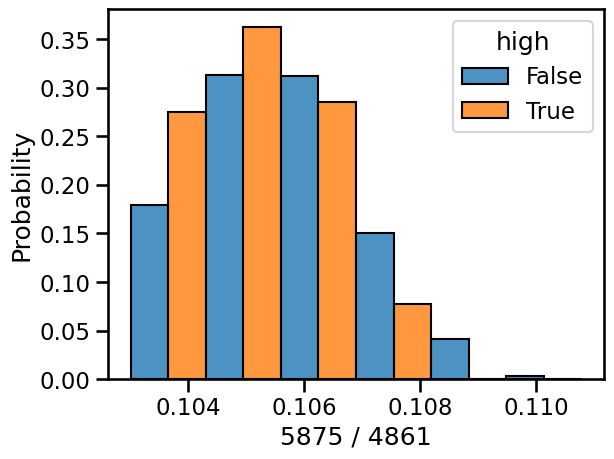

In [38]:
df["high"] = df["4686 / 4861"] > 0.003
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    multiple="dodge",
    shrink=1.0,
    stat="probability",
    common_norm=False,
    alpha=0.8,
    bins=6,
)

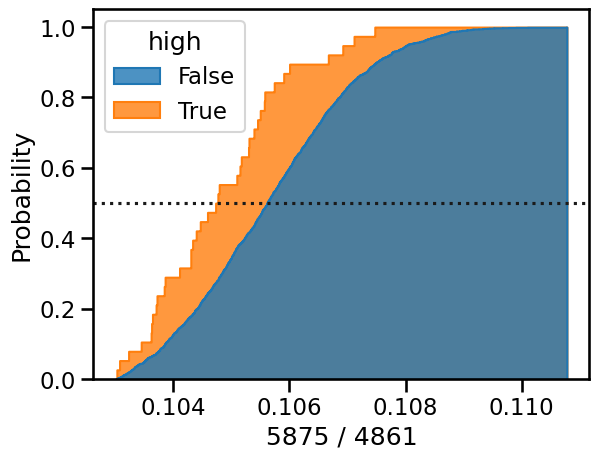

In [39]:
df["high"] = df["4686 / 4861"] > 0.005
sns.histplot(
    data=df,
    x="5875 / 4861",
    hue="high",
    # multiple="dodge",
    shrink=1.0,
    stat="probability",
    cumulative=True,
    common_norm=False,
    alpha=0.8,
    bins=1000,
    element="step",
).axhline(0.5, linestyle="dotted", color="k")

So, the depatterning improved the map but did not help with the statistics.

